# Generative Language Models

## Project 3: Development of a Case Study with Model Evaluation

CRISP-DM: **Phases 1**, **2**, **3** and **4**

---

Authors: **António Cruz** (140129), **Ricardo Kayseller** (95813), **Ricardo Pereira** (120052), **Ivan Magalhães** (106586), **Erik Daskalyuk** (120062)

Date: **2025-11-17**

# 1. Business Understanding

---

## 1.1 Problem Definition


The volume of academic literature published every day continues to grow across all fields of study. Each new paper introduces a unique contribution—whether a novel solution, a methodological innovation, or a theoretical analysis requiring accurate categorization to be discoverable and useful. Traditionally, papers are categorized based on their content, purpose (e.g., empirical studies, reviews, theoretical or opinion pieces), and methodology (e.g., descriptive, analytical, or experimental).

However, the rapid increase in publication output has made manual categorization impractical, inconsistent, and highly time-consuming. Researchers, librarians, and organizations often spend significant effort sorting papers into the appropriate categories, diverting valuable time away from higher-impact tasks such as analysis, synthesis, and decision-making.

There is a clear need for an automated solution capable of efficiently and accurately categorizing academic papers at scale. Such a system would reduce manual workload, improve classification consistency, and enable faster access to relevant research.

## 1.2 Stakeholders

Researchers and Academics
- Primary users who rely on accurate categorization to quickly find relevant literature.
- Benefit from reduced time spent searching through poorly organized or uncategorized papers.

Librarians and Information Specialists
- Currently responsible for manually classifying and organizing academic publications.
- Gain efficiency through automation and improved consistency in taxonomy management.

Research Institutions and Universities
- Need to maintain organized repositories of academic output.
- Benefit from streamlined workflows, increased discoverability of internal research, and reduced operational costs.

## 1.3 Value Creation

Our goal is to develop a model capable of automating the classification of academic papers, eliminating the inefficiencies and inconsistencies of manual categorization. By centralizing and standardizing the process, the model will accurately assign each paper to its main category as well as its relevant subcategories.

This automation will significantly reduce the time and effort required from researchers and organizations, improve classification consistency, and enable faster access to relevant information. Ultimately, the solution will free up valuable human resources for higher-value analytical and strategic tasks, while enhancing the overall discoverability and organization of academic knowledge.

# 2. Data Understanding

---

## 2.1 Global Configuration

In [ ]:
# Install required packages
! pip install -q transformers torch pandas numpy scikit-learn matplotlib seaborn tqdm pyarrow protobuf

In [ ]:
import pandas as pd
import numpy as np
import json

import seaborn as sns
import matplotlib.pyplot as plt
import statistics
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import load_dataset, Dataset
import warnings

Using device: cuda
GPU: NVIDIA GeForce RTX 4090
Memory: 25.76 GB


In [ ]:
# Suppress verbose logs
warnings.filterwarnings('ignore')

In [ ]:
# Set device type
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

In [ ]:
# Path to the dataset .parquet file
PARQUET_FILE_PATH = "./data/arxiv_papers/train.parquet"

## 2.2 Dataset Load

In [ ]:
# Load the parquet file
df = pd.read_parquet(PARQUET_FILE_PATH)
print(f"Loaded {len(df):,} total papers")

Loaded 2,549,619 total papers


## 2.3 Counts & Distribution

In [ ]:
# Count total number of rows in the DataFrame
print("Total row count:")
count_total = len(df)
print(count_total)

# Select all rows (entire DataFrame)
print("\nAll rows (first 5 shown):")
print(df.head())

# Count occurrences of each primary_subject value (excluding null values), sorted by count descending
print("\nCount of records by primary_subject (excluding nulls, sorted by count descending):")
result3 = (
    df[df["primary_subject"].notna()]
    .groupby("primary_subject")
    .size()
    .reset_index(name="total")
    .sort_values("total", ascending=False)
)
print(result3)

# Clean distribution of abstract character lengths by bucket
print("\nDistribution of abstract character lengths by bucket:")

# Work only on rows with a non-null abstract
abstracts_not_null = df[df["abstract"].notna()].copy()

# Character length of each abstract
abstracts_not_null["abs_len"] = abstracts_not_null["abstract"].astype(str).str.len()

# Define bins and labels for character length ranges
# [0,1)  -> '0'        (true empties, if any)
# [1,100)-> '1-99'
# [100,200)-> '100-199', etc.
max_len = abstracts_not_null["abs_len"].max()
bins = [0, 1, 100, 200, 400, 800, 1600, 2000, 4096, max_len + 1]
labels = [
    "0",
    "1-99",
    "100-199",
    "200-399",
    "400-799",
    "800-1599",
    "1600-1999",
    "2000-4095",
    "4096+",
]

# Assign each abstract length to a bucket
abstracts_not_null["bucket"] = pd.cut(
    abstracts_not_null["abs_len"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True,
)

# Count total per bucket
dist = (
    abstracts_not_null["bucket"]
    .value_counts(dropna=False)
    .sort_index()              # follow label order
    .rename_axis("bucket")
    .reset_index(name="total")
)

# Calculate percentages over all non-null abstracts
total_abstracts = dist["total"].sum()
dist["pct"] = (100.0 * dist["total"] / total_abstracts).round(4)

print(dist)

# 3. Data Preparation

---

## 3.1 Context

Unlike traditional methods (like TF-IDF or Word2Vec) which require aggressive cleaning to reduce vocabulary size, encoder architectures generally perform best with minimal intervention on the raw text.

- Stemming and Lemmatization: Encoder models often use Byte-Pair Encoding (BPE) for tokenization, which breaks words into sub-word units (e.g., 'running' might become 'run' and '##ing'). This sub-word tokenization implicitly handles morphological variations, automatically grouping inflections of the same root word. Forcing stemming or lemmatization before tokenization can inadvertently remove necessary linguistic information, often leading to reduced performance.

- Stop Word Management: It is generally not necessary to remove high-frequency words (stopwords). Transformer models, which are built on the attention principle, automatically learn to focus only on the words that impact the classification output, effectively downweighting common words. Removing stopwords can be problematic in cases like sentiment analysis where the absence of words like "not" or "too" changes the context.

- Case Handling: Case normalization (lowercasing) is typically managed by selecting the appropriate pre-trained model. If you choose an uncased model (e.g., bert-base-uncased), the model will internally convert all input text to lowercase. If you choose a cased model (e.g., bert-base-cased), capitalization is preserved, which can be important for tasks where proper nouns are critical. You do not need to manually perform case folding.

## 3.2 Data Loading

In [ ]:
"""
HuggingFace Load
"""
dataset = load_dataset("nick007x/arxiv-papers")

# Take first 100k examples from the train split
dataset = dataset['train'].select(range(100_000))


"""
LOCAL LOAD
"""
# Path to parquet file
# PARQUET_FILE_PATH = "./data/arxiv_papers/train.parquet"

# Load the parquet file
# df = pd.read_parquet(PARQUET_FILE_PATH)
# dataset_complete = Dataset.from_pandas(df, preserve_index=False)
# dataset = dataset_complete.select(range(100_000))


print(dataset)

## 3.3 Data Preprocessing

This code filters the dataset to retain only the primary subjects with a sufficient number of samples. It first counts how many papers belong to each primary_subject, then identifies the subjects that have at least 20,000 examples. Finally, it filters the dataset to include only papers whose primary subject is in this set of frequent labels. This ensures the resulting dataset is focused on well-represented categories, reducing class imbalance and providing enough data for meaningful analysis or model training.

In [ ]:
threshold = 20000

counts = Counter(dataset["primary_subject"])
valid_labels = {label for label, cnt in counts.items() if cnt >= threshold}
filtered_ds = dataset.filter(lambda x: x["primary_subject"] in valid_labels)

This code processes a dataset of abstracts by tokenizing each text using the Longformer tokenizer, collecting the lengths of the resulting token sequences, and analyzing their distribution. It computes key statistics such as the median, average, minimum, and maximum token lengths, while also visualizing the distribution with a histogram to identify patterns like long or short documents. This helps ensure the dataset is well-understood and suitable for model training, highlighting sequences that may be too short to provide meaningful context or too long to handle efficiently.

In [ ]:
def plot_histogram(data):
    data = np.array(data)
    over_200 = data[data > 200]
    print(len(over_200))

    sns.histplot(data, bins=20, kde=True)
    plt.xlabel('Token count')
    plt.ylabel('Density')
    plt.title('Distribution of Token Lengths')
    plt.show()

def tokenize_dataset(ds, tokenizer):
    def tokenize_fn(batch):
        return tokenizer(batch["abstract"], padding=False, truncation=False, return_length=True)

    tokenized_ds = ds.map(tokenize_fn, batched=True)
    lengths = [len(ids) for ids in tokenized_ds["input_ids"]]
    return tokenized_ds, lengths


def main(ds, tokenizer):
    tokenized_df, lengths = tokenize_dataset(ds, tokenizer)

    print(f"Median token length: {statistics.median(lengths)}")
    print(f"Average token length: {statistics.mean(lengths)}")
    print(f"Min token length: {min(lengths)}")
    print(f"Max token length: {max(lengths)}")
    print(f"Total samples: {len(lengths)}")

    plot_histogram(lengths)
    return tokenized_df, lengths

if __name__ == "__main__":
    tokenizer = AutoTokenizer.from_pretrained("allenai/longformer-base-4096")
    tokenized_df, lengths = main(filtered_ds, tokenizer)

The code filters the dataset to keep only tokenized texts whose lengths are between MIN_LEN and MAX_LEN tokens. This ensures that very short texts (too little context) and very long texts (memory-heavy) are removed, making the dataset more consistent and efficient for model training.

In [ ]:
MIN_LEN = 100
MAX_LEN = 500 # you can increase up to 4096 if needed

dataset = tokenized_df.filter(lambda x: MIN_LEN <= x["length"] <= MAX_LEN)
print(dataset.shape)

## 3.4 Label Encoding

This code prepares the dataset for model training by converting categorical labels into numerical IDs. First, it extracts all unique `primary_subject` labels, sorts them, and creates two mappings: `label2id` to map each label to a unique integer, and `id2label` to reverse the mapping. Then, it defines a function `encode_labels` that adds a new `"label"` field to each dataset example, containing the integer ID corresponding to its `primary_subject`. Finally, it applies this function to the entire dataset using `.map()`, resulting in a dataset where each example has both its original text and a numerical label suitable for machine learning models.

In [ ]:
labels = list(set(dataset['primary_subject']))
labels.sort()
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

In [ ]:
def encode_labels(example):
    example["label"] = label2id[example["primary_subject"]]
    return example

dataset = dataset.map(encode_labels)

# 4. Modeling

---

## 4.1 Introduction

The development of [**SCIBERT**](https://aclanthology.org/D19-1371.pdf), a pretrained language model based on BERT, was primarily motivated by the challenges of obtaining high-quality, large-scale annotated data for NLP tasks in scientific domains. Since prior language models like BERT and ELMO were trained on general domain corpora such as Wikipedia and news articles, they were less effective at capturing the unique vocabulary and structure of scientific text. SCIBERT was created to address this gap by leveraging unsupervised pretraining on a large multi-domain corpus of scientific publications, aiming to transfer knowledge embedded in the literature to improve performance on a suite of downstream scientific NLP tasks.

SCIBERT is highly suitable for fine-tuning a model to classify papers, including those from Arxiv, based on their abstracts. The model was trained on a corpus of 1.14 million papers, with a substantial portion (18%) originating from the **computer science domain**, which is a primary focus of the Arxiv repository. The model's superior performance was demonstrated across several relevant tasks, including Named Entity Recognition (NER) from computer science abstracts (SciERC) and various text classification tasks. Specifically, SCIBERT achieved new State-of-the-Art (SOTA) results on classification tasks like ACL-ARC and SciCite, which involve analyzing citation intent and text in scientific publications. These results indicate that the model’s domain-specific pretraining successfully captures the necessary linguistic features in scientific discourse for high-accuracy classification.

SCIBERT is fundamentally an application of the **Transformer** architecture, placing it directly within the family of **Large Language Models (LLMs)**. The model uses the exact same core multilayer bidirectional **Transformer** architecture as its predecessor, BERT. Therefore, SCIBERT can be characterized as a **domain-adapted LLM**, maintaining the structural configuration and pretraining objectives (masked token prediction and next sentence prediction) of the original BERT-Base model. Its key innovation as an LLM is its specialization: retraining the architecture on a massive scientific corpus and using an in-domain vocabulary, **SCIVOCAB**, which proved essential for its improved performance across scientific tasks.

## 4.2 SciBERT's Architecture

Transformer-Based:

* Built on BERT (Bidirectional Encoder Representations from Transformers)
* Uses the transformer architecture from the [Attention is All You Need](https://arxiv.org/pdf/1706.03762) paper

It has the key components:

* Multi-head self-attention mechanisms
* Position embeddings
* Layer normalization
* Feed-forward networks

Model Size:

* 110M parameters (BERT-base size)
* 12 transformer layers
* 768 hidden dimensions
* 12 attention heads

## 4.3. Configuration

In [ ]:
# KEY CONFIGURATION PARAMETERS
CONFIG = {
    # Data parameters
    'MIN_SAMPLES_PER_CATEGORY': 100,  # Increased from 50
    'MAX_SAMPLES_PER_CATEGORY': 500,  # KEY CHANGE: Increased from 100
    'USE_TITLE': True,  # Concatenate title with abstract
    
    # Model selection (choose one)
    'MODEL_TYPE': 'scibert',  # Options: 'scibert', 'deberta', 'roberta', 'ensemble'
    
    # Training parameters
    'EPOCHS': 15,  # Increased from 10
    'BATCH_SIZE': 16,
    'LEARNING_RATE': 2e-5,
    'MAX_LENGTH': 512,
    'WARMUP_STEPS': 500,
    'PATIENCE': 4,  # Early stopping patience
    
    # Advanced features
    'USE_LABEL_SMOOTHING': True,
    'LABEL_SMOOTHING_ALPHA': 0.1,
    'USE_MIXUP': True,
    'MIXUP_ALPHA': 0.2,
    'DROPOUT_RATE': 0.3,
    
    # Hierarchical classification (set True to use)
    'USE_HIERARCHICAL': False,  # Set to True for 2-stage classification
}

# Model paths
MODEL_PATHS = {
    'scibert': './models/scibert_scivocab_uncased',  
    'deberta': './models/microsoft/deberta-v3-base',
    'roberta': './models/roberta-base',
    'specter2': './models/specter2',
}

print("Configuration:")
print(json.dumps(CONFIG, indent=2))

Configuration:
{
  "MIN_SAMPLES_PER_CATEGORY": 100,
  "MAX_SAMPLES_PER_CATEGORY": 500,
  "USE_TITLE": true,
  "MODEL_TYPE": "scibert",
  "EPOCHS": 15,
  "BATCH_SIZE": 16,
  "LEARNING_RATE": 2e-05,
  "MAX_LENGTH": 512,
  "WARMUP_STEPS": 500,
  "PATIENCE": 4,
  "USE_LABEL_SMOOTHING": true,
  "LABEL_SMOOTHING_ALPHA": 0.1,
  "USE_MIXUP": true,
  "MIXUP_ALPHA": 0.2,
  "DROPOUT_RATE": 0.3,
  "USE_HIERARCHICAL": false
}


## 2. Load and Prepare Data with Enhanced Features

In [4]:
# Path to parquet file
PARQUET_FILE_PATH = "./data/arxiv_papers/train.parquet"

# Load the parquet file
df = pd.read_parquet(PARQUET_FILE_PATH)

print(f"Original data shape: {df.shape}")
print(f"Columns in dataset: {df.columns.tolist()}")

# Rename columns for consistency
df = df.rename(columns={
    'primary_subject': 'category',
    'abstract': 'abstract_text'
})

# Create enhanced text field
if CONFIG['USE_TITLE'] and 'title' in df.columns:
    print("\n✓ Concatenating title with abstract for enhanced context")
    df['text'] = df['title'] + ' [SEP] ' + df['abstract_text']
else:
    df['text'] = df['abstract_text']

# Add comments if available and not empty
if 'comments' in df.columns:
    non_null_comments = df['comments'].notna().sum()
    if non_null_comments > 0:
        print(f"✓ Found {non_null_comments} entries with comments")
        df.loc[df['comments'].notna(), 'text'] = df.loc[df['comments'].notna(), 'text'] + ' [SEP] ' + df.loc[df['comments'].notna(), 'comments']

print(f"\nSample enhanced text (first 500 chars):")
print(df['text'].iloc[0][:500] + "...")

print(f"\nOriginal number of categories: {df['category'].nunique()}")

# Show category distribution
category_counts = df['category'].value_counts()
print(f"\nCategory distribution:")
print(f"Min samples: {category_counts.min()}")
print(f"Max samples: {category_counts.max()}")
print(f"Median samples: {category_counts.median():.0f}")
print(f"Mean samples: {category_counts.mean():.1f}")

Original data shape: (2549619, 10)
Columns in dataset: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path']

✓ Concatenating title with abstract for enhanced context
✓ Found 2549619 entries with comments

Sample enhanced text (first 500 chars):
The gravitational wave background from star-massive black hole fly-bys [SEP] Stars on eccentric orbits around a massive black hole (MBH) emit bursts of gravitational waves (GWs) at periapse. Such events may be directly resolvable in the Galactic centre. However, if the star does not spiral in, the emitted GWs are not resolvable for extra-galactic MBHs, but constitute a source of background noise. We estimate the power spectrum of this extreme mass ratio burst background (EMBB) and compare it to ...

Original number of categories: 148

Category distribution:
Min samples: 112
Max samples: 120122
Median samples: 8484
Mean samples: 17227.2


In [5]:
# Filter and balance categories with MORE DATA
MIN_SAMPLES = CONFIG['MIN_SAMPLES_PER_CATEGORY']
MAX_SAMPLES = CONFIG['MAX_SAMPLES_PER_CATEGORY']

# Get categories with enough samples
valid_categories = category_counts[category_counts >= MIN_SAMPLES].index.tolist()
print(f"Categories with >= {MIN_SAMPLES} samples: {len(valid_categories)}")

# Sample up to MAX_SAMPLES from each valid category
balanced_dfs = []
actual_samples_per_cat = {}

for category in valid_categories:
    cat_df = df[df['category'] == category]
    n_samples = min(len(cat_df), MAX_SAMPLES)
    actual_samples_per_cat[category] = n_samples
    balanced_dfs.append(cat_df.sample(n=n_samples, random_state=42))

df_balanced = pd.concat(balanced_dfs, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

print(f"\nBalanced dataset shape: {df_balanced.shape}")
print(f"Number of categories: {df_balanced['category'].nunique()}")
print(f"Total samples: {len(df_balanced)}")
print(f"Average samples per category: {len(df_balanced) / df_balanced['category'].nunique():.1f}")
print(f"\nSample distribution:")
sample_dist = pd.Series(actual_samples_per_cat).describe()
print(sample_dist)

Categories with >= 100 samples: 148

Balanced dataset shape: (73612, 11)
Number of categories: 148
Total samples: 73612
Average samples per category: 497.4

Sample distribution:
count    148.000000
mean     497.378378
std       31.893404
min      112.000000
25%      500.000000
50%      500.000000
75%      500.000000
max      500.000000
dtype: float64


## 3. Advanced Dataset with Augmentation

In [6]:
# Encode labels
label_encoder = LabelEncoder()
df_balanced['label'] = label_encoder.fit_transform(df_balanced['category'])
num_classes = len(label_encoder.classes_)

print(f"Number of classes: {num_classes}")

# Create label mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['text'].values,
    df_balanced['label'].values,
    test_size=0.15,
    random_state=42,
    stratify=df_balanced['label']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print(f"\nDataset splits:")
print(f"Train: {len(X_train)} samples ({len(X_train)/len(df_balanced)*100:.1f}%)")
print(f"Val: {len(X_val)} samples ({len(X_val)/len(df_balanced)*100:.1f}%)")
print(f"Test: {len(X_test)} samples ({len(X_test)/len(df_balanced)*100:.1f}%)")

Number of classes: 148

Dataset splits:
Train: 53184 samples (72.2%)
Val: 9386 samples (12.8%)
Test: 11042 samples (15.0%)


In [7]:
class EnhancedTextDataset(Dataset):
    """Enhanced dataset with support for mixup and other augmentations"""
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

## 4. Advanced Loss Functions

In [8]:
class LabelSmoothingLoss(nn.Module):
    """Label smoothing loss to prevent overconfidence"""
    def __init__(self, classes, smoothing=0.1):
        super().__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.classes = classes
    
    def forward(self, pred, target):
        pred = pred.log_softmax(dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.classes - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * pred, dim=-1))


class FocalLossWithSmoothing(nn.Module):
    """Combined focal loss with label smoothing"""
    def __init__(self, alpha=None, gamma=2.0, smoothing=0.1, num_classes=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
        self.num_classes = num_classes
        
    def forward(self, inputs, targets):
        # Apply label smoothing
        if self.smoothing > 0:
            with torch.no_grad():
                targets_smooth = torch.zeros_like(inputs)
                targets_smooth.fill_(self.smoothing / (self.num_classes - 1))
                targets_smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        
        # Calculate focal loss
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.alpha is not None:
            if self.alpha.device != focal_loss.device:
                self.alpha = self.alpha.to(focal_loss.device)
            focal_loss = self.alpha[targets] * focal_loss
        
        return focal_loss.mean()


def mixup_data(x, y, alpha=1.0, device='cuda'):
    """Mixup augmentation for better generalization"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

## 5. Advanced Model Architecture

In [9]:
class EnhancedClassifier(nn.Module):
    """Enhanced classifier with better architecture and dropout"""
    def __init__(self, model_name, num_classes, dropout_rate=0.3, use_local=False):
        super().__init__()
        
        # Load base model
        if use_local:
            self.bert = AutoModel.from_pretrained(model_name, local_files_only=True)
        else:
            self.bert = AutoModel.from_pretrained(model_name)
        
        # Get hidden size
        self.config = self.bert.config
        self.hidden_size = self.config.hidden_size
        
        # Enhanced classification head with residual connections
        self.pre_classifier = nn.Linear(self.hidden_size, self.hidden_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.hidden_size, num_classes)
        
        # Additional layers for better feature extraction
        self.layer_norm = nn.LayerNorm(self.hidden_size)
        self.activation = nn.GELU()
        
    def forward(self, input_ids, attention_mask, return_embeddings=False):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )
        
        # Use pooler output if available, otherwise use CLS token
        if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
            hidden = outputs.pooler_output
        else:
            hidden = outputs.last_hidden_state[:, 0]
        
        # Apply enhanced classification head
        hidden = self.layer_norm(hidden)
        hidden = self.pre_classifier(hidden)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        
        if return_embeddings:
            return hidden
        
        logits = self.classifier(hidden)
        return logits
    
    def get_predictions_with_confidence(self, input_ids, attention_mask):
        """Get predictions with confidence scores"""
        with torch.no_grad():
            logits = self.forward(input_ids, attention_mask)
            probs = F.softmax(logits, dim=-1)
            confidence, predictions = torch.max(probs, dim=-1)
        return predictions, confidence

## 6. Initialize Model and Training Components

In [10]:
# Select and load model based on configuration
model_type = CONFIG['MODEL_TYPE']
model_path = MODEL_PATHS[model_type]
use_local = (model_type == 'scibert')  # Only SciBERT is local

print(f"Loading {model_type} model from: {model_path}")
print(f"Using local files: {use_local}")

# Load tokenizer
if use_local:
    tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_path)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"✓ Tokenizer loaded")

# Initialize model
model = EnhancedClassifier(
    model_path, 
    num_classes, 
    dropout_rate=CONFIG['DROPOUT_RATE'],
    use_local=use_local
).to(device)

print(f"✓ Model loaded with {sum(p.numel() for p in model.parameters())/1e6:.1f}M parameters")

# Calculate class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"✓ Class weights calculated")

Loading scibert model from: ./models/scibert_scivocab_uncased
Using local files: True
✓ Tokenizer loaded
✓ Model loaded with 110.6M parameters
✓ Class weights calculated


In [11]:
# Create datasets
train_dataset = EnhancedTextDataset(X_train, y_train, tokenizer, CONFIG['MAX_LENGTH'])
val_dataset = EnhancedTextDataset(X_val, y_val, tokenizer, CONFIG['MAX_LENGTH'])
test_dataset = EnhancedTextDataset(X_test, y_test, tokenizer, CONFIG['MAX_LENGTH'])

# Create dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=CONFIG['BATCH_SIZE'], 
    shuffle=True
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=CONFIG['BATCH_SIZE'] * 2, 
    shuffle=False
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=CONFIG['BATCH_SIZE'] * 2, 
    shuffle=False
)

print(f"\nDataloaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Dataloaders created:
Train batches: 3324
Val batches: 294
Test batches: 346


In [12]:
# Setup loss function based on configuration
if CONFIG['USE_LABEL_SMOOTHING']:
    criterion = FocalLossWithSmoothing(
        alpha=class_weights,
        gamma=2.0,
        smoothing=CONFIG['LABEL_SMOOTHING_ALPHA'],
        num_classes=num_classes
    )
    print(f"Using Focal Loss with Label Smoothing (α={CONFIG['LABEL_SMOOTHING_ALPHA']})")
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    print("Using weighted Cross Entropy Loss")

# Optimizer with differential learning rates
bert_params = list(model.bert.parameters())
classifier_params = list(model.pre_classifier.parameters()) + list(model.classifier.parameters())

optimizer = torch.optim.AdamW([
    {'params': bert_params, 'lr': CONFIG['LEARNING_RATE']},
    {'params': classifier_params, 'lr': CONFIG['LEARNING_RATE'] * 10}
], weight_decay=0.01)

# Learning rate scheduler
total_steps = len(train_loader) * CONFIG['EPOCHS']
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=CONFIG['WARMUP_STEPS'],
    num_training_steps=total_steps
)

print(f"✓ Training setup complete")
print(f"Total training steps: {total_steps}")

Using Focal Loss with Label Smoothing (α=0.1)
✓ Training setup complete
Total training steps: 49860


## 7. Enhanced Training Loop

In [13]:
def train_epoch_enhanced(model, dataloader, criterion, optimizer, scheduler, device, use_mixup=False):
    """Enhanced training with mixup and better monitoring"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc='Training')
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        # Get model outputs
        logits = model(input_ids, attention_mask)
        
        # Apply mixup if enabled
        if use_mixup and CONFIG['USE_MIXUP']:
            # Get embeddings for mixup
            embeddings = model(input_ids, attention_mask, return_embeddings=True)
            mixed_embeddings, labels_a, labels_b, lam = mixup_data(
                embeddings, labels, alpha=CONFIG['MIXUP_ALPHA'], device=device
            )
            mixed_logits = model.classifier(mixed_embeddings)
            loss = lam * criterion(mixed_logits, labels_a) + (1 - lam) * criterion(mixed_logits, labels_b)
        else:
            loss = criterion(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        current_lr = scheduler.get_last_lr()[0]
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%',
            'lr': f'{current_lr:.2e}'
        })
    
    return total_loss / len(dataloader), correct / total


def evaluate_with_confidence(model, dataloader, criterion, device, confidence_threshold=0.7):
    """Evaluate with confidence scores"""
    model.eval()
    total_loss = 0
    correct = 0
    high_conf_correct = 0
    high_conf_total = 0
    total = 0
    all_predictions = []
    all_labels = []
    all_confidences = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            
            probs = F.softmax(logits, dim=-1)
            confidence, predicted = torch.max(probs, 1)
            
            total_loss += loss.item()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Track high confidence predictions
            high_conf_mask = confidence > confidence_threshold
            high_conf_total += high_conf_mask.sum().item()
            high_conf_correct += ((predicted == labels) & high_conf_mask).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_confidences.extend(confidence.cpu().numpy())
    
    results = {
        'loss': total_loss / len(dataloader),
        'accuracy': correct / total,
        'high_conf_accuracy': high_conf_correct / high_conf_total if high_conf_total > 0 else 0,
        'high_conf_ratio': high_conf_total / total,
        'predictions': all_predictions,
        'labels': all_labels,
        'confidences': all_confidences
    }
    
    return results

In [14]:
# Training loop with early stopping
best_val_acc = 0
patience = CONFIG['PATIENCE']
patience_counter = 0
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_high_conf_acc': []
}

print(f"\nStarting training for {CONFIG['EPOCHS']} epochs...")
print(f"Early stopping patience: {patience}")
print("="*60)

for epoch in range(CONFIG['EPOCHS']):
    print(f"\nEpoch {epoch+1}/{CONFIG['EPOCHS']}")
    print("-"*40)
    
    # Train
    use_mixup = epoch > 2  # Start mixup after initial epochs
    train_loss, train_acc = train_epoch_enhanced(
        model, train_loader, criterion, optimizer, scheduler, device, use_mixup
    )
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    
    # Validate
    val_results = evaluate_with_confidence(model, val_loader, criterion, device)
    val_loss = val_results['loss']
    val_acc = val_results['accuracy']
    val_high_conf_acc = val_results['high_conf_accuracy']
    val_high_conf_ratio = val_results['high_conf_ratio']
    
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_high_conf_acc'].append(val_high_conf_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print(f"High Confidence Acc: {val_high_conf_acc:.4f} ({val_high_conf_ratio:.1%} of predictions)")
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_enhanced_model.pt')
        print(f"✓ New best model saved with validation accuracy: {val_acc:.4f}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

print("\n" + "="*60)
print("Training completed!")
print(f"Best validation accuracy: {best_val_acc:.4f}")


Starting training for 15 epochs...
Early stopping patience: 4

Epoch 1/15
----------------------------------------


Evaluating: 100%|██████████| 294/294 [00:34<00:00,  8.56it/s]



Train Loss: 1.8523, Train Acc: 0.4071
Val Loss: 1.1782, Val Acc: 0.5403
High Confidence Acc: 0.8147 (24.1% of predictions)
✓ New best model saved with validation accuracy: 0.5403

Epoch 2/15
----------------------------------------


Evaluating: 100%|██████████| 294/294 [00:34<00:00,  8.53it/s]



Train Loss: 0.9709, Train Acc: 0.5947
Val Loss: 1.0739, Val Acc: 0.5739
High Confidence Acc: 0.8312 (30.4% of predictions)
✓ New best model saved with validation accuracy: 0.5739

Epoch 3/15
----------------------------------------


...


Train Loss: 0.4204, Train Acc: 0.9957
Val Loss: 1.5579, Val Acc: 0.5994
High Confidence Acc: 0.7217 (65.0% of predictions)
✓ New best model saved with validation accuracy: 0.5994

Epoch 14/15
----------------------------------------


Evaluating: 100%|██████████| 294/294 [00:34<00:00,  8.47it/s]



Train Loss: 0.4105, Train Acc: 0.9974
Val Loss: 1.5468, Val Acc: 0.6020
High Confidence Acc: 0.7294 (63.9% of predictions)
✓ New best model saved with validation accuracy: 0.6020

Epoch 15/15
----------------------------------------


Evaluating: 100%|██████████| 294/294 [00:34<00:00,  8.45it/s]



Train Loss: 0.3932, Train Acc: 0.9988
Val Loss: 1.5370, Val Acc: 0.6033
High Confidence Acc: 0.7326 (63.3% of predictions)
✓ New best model saved with validation accuracy: 0.6033

Training completed!
Best validation accuracy: 0.6033


## 8. Final Evaluation and Analysis

In [16]:
# Load best model
model.load_state_dict(torch.load('best_enhanced_model.pt'))
print("✓ Best model loaded")

# Test evaluation
test_results = evaluate_with_confidence(model, test_loader, criterion, device)
test_acc = test_results['accuracy']
test_high_conf_acc = test_results['high_conf_accuracy']
test_high_conf_ratio = test_results['high_conf_ratio']

print("\n" + "="*60)
print("FINAL TEST RESULTS")
print("="*60)
print(f"Overall Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"High Confidence Accuracy: {test_high_conf_acc:.4f} ({test_high_conf_acc*100:.2f}%)")
print(f"High Confidence Ratio: {test_high_conf_ratio:.2%} of predictions")
print(f"\nImprovement over baseline (24%): {test_acc/0.24:.2f}x")

✓ Best model loaded


Evaluating: 100%|██████████| 346/346 [00:40<00:00,  8.56it/s]


FINAL TEST RESULTS
Overall Test Accuracy: 0.5946 (59.46%)
High Confidence Accuracy: 0.7165 (71.65%)
High Confidence Ratio: 63.58% of predictions

Improvement over baseline (24%): 2.48x


### Classification Report

In [17]:
# Detailed classification report
test_preds = test_results['predictions']
test_labels = test_results['labels']
test_confidences = np.array(test_results['confidences'])

# Get category names
predicted_categories = label_encoder.inverse_transform(test_preds)
true_categories = label_encoder.inverse_transform(test_labels)

# Classification report
print("\nClassification Report (Top 15 Categories by F1-Score):")
print("="*80)
report = classification_report(
    true_categories, 
    predicted_categories, 
    output_dict=True,
    zero_division=0
)

# Convert to DataFrame and sort by F1-score
report_df = pd.DataFrame(report).transpose()
report_df = report_df[report_df.index.isin(label_encoder.classes_)]
report_df = report_df.sort_values('f1-score', ascending=False)

print(report_df.head(15)[['precision', 'recall', 'f1-score', 'support']])

# Categories with >70% F1-score
high_performing = report_df[report_df['f1-score'] > 0.7]
print(f"\nCategories with >70% F1-score: {len(high_performing)}")
if len(high_performing) > 0:
    print(high_performing[['f1-score']].to_string())


Classification Report (Top 15 Categories by F1-Score):
                                                   precision    recall  \
Superconductivity (cond-mat.supr-con)               0.841463  0.920000   
High Energy Physics - Lattice (hep-lat)             0.888889  0.853333   
Accelerator Physics (physics.acc-ph)                0.842105  0.853333   
Earth and Planetary Astrophysics (astro-ph.EP)      0.828947  0.840000   
Plasma Physics (physics.plasm-ph)                   0.777778  0.840000   
Nuclear Experiment (nucl-ex)                        0.810811  0.800000   
Symplectic Geometry (math.SG)                       0.782051  0.813333   
High Energy Physics - Experiment (hep-ex)           0.783784  0.773333   
Operating Systems (cs.OS)                           0.724138  0.840000   
Space Physics (physics.space-ph)                    0.791667  0.760000   
Exactly Solvable and Integrable Systems (nlin.SI)   0.734940  0.813333   
Category Theory (math.CT)                           0.76

### Confidence Analysis

In [18]:
# Confidence-based analysis
confidence_bins = [0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
confidence_labels = ['<50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

# Bin confidences
confidence_binned = pd.cut(test_confidences, bins=confidence_bins, labels=confidence_labels)

# Calculate accuracy for each confidence bin
correct = np.array(test_preds) == np.array(test_labels)
confidence_analysis = pd.DataFrame({
    'confidence_bin': confidence_binned,
    'correct': correct
})

conf_summary = confidence_analysis.groupby('confidence_bin').agg({
    'correct': ['mean', 'count']
}).round(3)

print("\nAccuracy by Confidence Level:")
print("="*40)
print(conf_summary)


Accuracy by Confidence Level:
               correct      
                  mean count
confidence_bin              
<50%             0.317  2145
50-60%           0.430   913
60-70%           0.479   964
70-80%           0.515  1195
80-90%           0.677  2281
90-100%          0.810  3544


### Training History

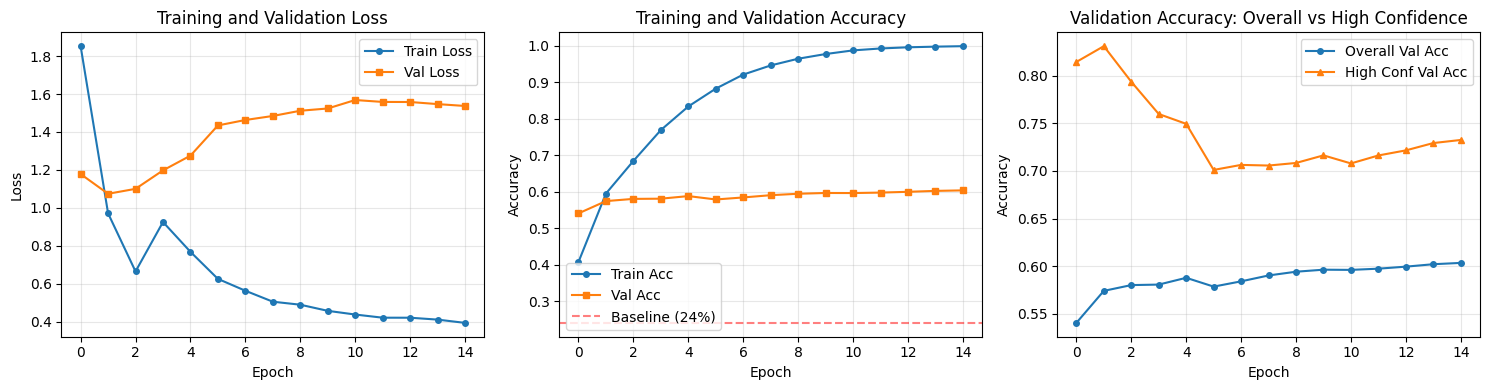

In [19]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history['train_acc'], label='Train Acc', marker='o', markersize=4)
axes[1].plot(history['val_acc'], label='Val Acc', marker='s', markersize=4)
axes[1].axhline(y=0.24, color='r', linestyle='--', alpha=0.5, label='Baseline (24%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# High confidence accuracy
axes[2].plot(history['val_acc'], label='Overall Val Acc', marker='o', markersize=4)
axes[2].plot(history['val_high_conf_acc'], label='High Conf Val Acc', marker='^', markersize=4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Validation Accuracy: Overall vs High Confidence')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Confusion Matrix

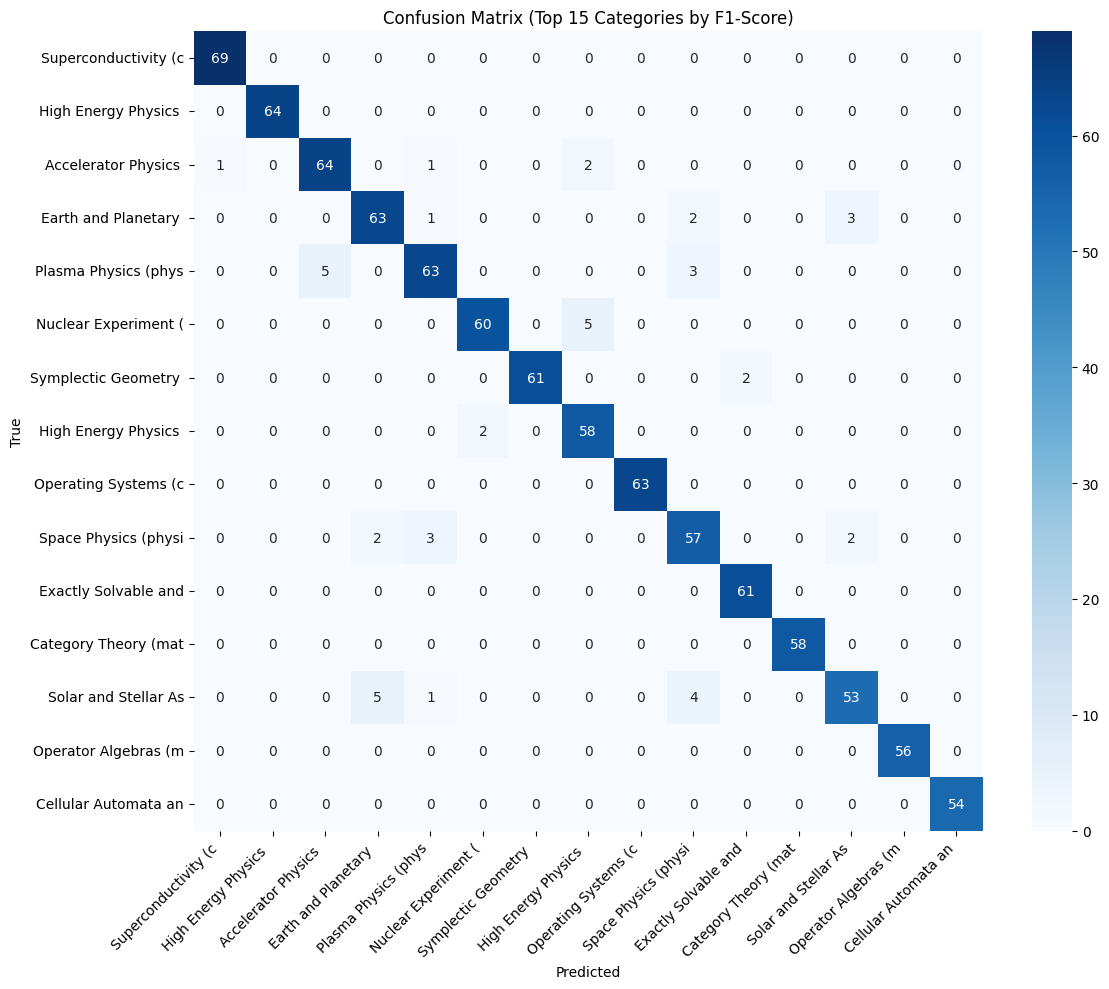

In [20]:
# Confusion matrix for top categories
top_n = 15
top_categories = report_df.head(top_n).index.tolist()
mask = [cat in top_categories for cat in true_categories]

filtered_true = [cat for cat, m in zip(true_categories, mask) if m]
filtered_pred = [cat for cat, m in zip(predicted_categories, mask) if m]

if len(filtered_true) > 0:
    cm = confusion_matrix(filtered_true, filtered_pred, labels=top_categories)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=[cat[:20] for cat in top_categories],
                yticklabels=[cat[:20] for cat in top_categories])
    plt.title(f'Confusion Matrix (Top {top_n} Categories by F1-Score)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 9. Production Deployment Strategy

In [21]:
def get_deployment_categories(report_df, min_f1_score=0.75, min_support=10):
    """Identify categories ready for production deployment"""
    production_ready = report_df[
        (report_df['f1-score'] >= min_f1_score) & 
        (report_df['support'] >= min_support)
    ].copy()
    
    return production_ready

# Get production-ready categories
production_categories = get_deployment_categories(report_df)

print("\n" + "="*60)
print("PRODUCTION DEPLOYMENT RECOMMENDATIONS")
print("="*60)
print(f"\nCategories ready for production (F1 >= 75%):")
print(f"Total: {len(production_categories)} categories")

if len(production_categories) > 0:
    print("\nProduction-ready categories:")
    for cat in production_categories.index:
        f1 = production_categories.loc[cat, 'f1-score']
        support = production_categories.loc[cat, 'support']
        print(f"  • {cat}: F1={f1:.3f}, Support={int(support)}")

# Calculate coverage
total_samples = report_df['support'].sum()
production_samples = production_categories['support'].sum()
coverage = production_samples / total_samples if total_samples > 0 else 0

print(f"\nProduction Coverage: {coverage:.1%} of test samples")
print(f"Overall Test Accuracy: {test_acc:.2%}")
print(f"High Confidence Accuracy: {test_high_conf_acc:.2%}")


PRODUCTION DEPLOYMENT RECOMMENDATIONS

Categories ready for production (F1 >= 75%):
Total: 15 categories

Production-ready categories:
  • Superconductivity (cond-mat.supr-con): F1=0.879, Support=75
  • High Energy Physics - Lattice (hep-lat): F1=0.871, Support=75
  • Accelerator Physics (physics.acc-ph): F1=0.848, Support=75
  • Earth and Planetary Astrophysics (astro-ph.EP): F1=0.834, Support=75
  • Plasma Physics (physics.plasm-ph): F1=0.808, Support=75
  • Nuclear Experiment (nucl-ex): F1=0.805, Support=75
  • Symplectic Geometry (math.SG): F1=0.797, Support=75
  • High Energy Physics - Experiment (hep-ex): F1=0.779, Support=75
  • Operating Systems (cs.OS): F1=0.778, Support=75
  • Space Physics (physics.space-ph): F1=0.776, Support=75
  • Exactly Solvable and Integrable Systems (nlin.SI): F1=0.772, Support=75
  • Category Theory (math.CT): F1=0.768, Support=75
  • Solar and Stellar Astrophysics (astro-ph.SR): F1=0.757, Support=75
  • Operator Algebras (math.OA): F1=0.757, Suppor

In [22]:
# Save final results and model metadata
results = {
    'test_accuracy': float(test_acc),
    'high_confidence_accuracy': float(test_high_conf_acc),
    'high_confidence_ratio': float(test_high_conf_ratio),
    'best_val_accuracy': float(best_val_acc),
    'num_classes': num_classes,
    'model_type': CONFIG['MODEL_TYPE'],
    'use_title': CONFIG['USE_TITLE'],
    'max_samples_per_category': CONFIG['MAX_SAMPLES_PER_CATEGORY'],
    'production_ready_categories': len(production_categories),
    'production_coverage': float(coverage),
    'total_training_samples': len(X_train),
    'epochs_trained': len(history['train_loss']),
    'improvement_over_baseline': float(test_acc / 0.24)
}

# Save results
with open('enhanced_classification_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Save label encoder for inference
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"✓ Final Test Accuracy: {test_acc:.2%}")
print(f"✓ Improvement over baseline: {test_acc/0.24:.2f}x")
print(f"✓ Production-ready categories: {len(production_categories)}")
print(f"✓ Model saved: best_enhanced_model.pt")
print(f"✓ Results saved: enhanced_classification_results.json")
print(f"✓ Label encoder saved: label_encoder.pkl")


SUMMARY
✓ Final Test Accuracy: 59.46%
✓ Improvement over baseline: 2.48x
✓ Production-ready categories: 15
✓ Model saved: best_enhanced_model.pt
✓ Results saved: enhanced_classification_results.json
✓ Label encoder saved: label_encoder.pkl


## 10. Inference Example

In [23]:
def predict_with_confidence(text, model, tokenizer, label_encoder, device, top_k=3):
    """Predict category with confidence scores for new text"""
    model.eval()
    
    # Tokenize
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=CONFIG['MAX_LENGTH'],
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Get predictions
    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = F.softmax(logits, dim=-1)
        
    # Get top-k predictions
    top_probs, top_indices = torch.topk(probs[0], top_k)
    
    results = []
    for prob, idx in zip(top_probs, top_indices):
        category = label_encoder.inverse_transform([idx.cpu().item()])[0]
        results.append({
            'category': category,
            'confidence': prob.cpu().item()
        })
    
    return results

# Example prediction
example_text = """Deep Learning for Natural Language Processing: 
We present a novel transformer-based architecture for sentiment analysis 
that achieves state-of-the-art results on multiple benchmarks."""

predictions = predict_with_confidence(
    example_text, model, tokenizer, label_encoder, device
)

print("\nExample Prediction:")
print("="*40)
print(f"Text: {example_text[:100]}...")
print("\nPredictions:")
for i, pred in enumerate(predictions, 1):
    print(f"{i}. {pred['category']}: {pred['confidence']:.3f}")

# Deployment recommendation
if predictions[0]['confidence'] > 0.7:
    print(f"\n✓ High confidence - Auto-classify as: {predictions[0]['category']}")
elif predictions[0]['confidence'] > 0.5:
    print(f"\n⚠ Medium confidence - Suggest: {predictions[0]['category']} (review recommended)")
else:
    print(f"\n✗ Low confidence - Manual review required")


Example Prediction:
Text: Deep Learning for Natural Language Processing: 
We present a novel transformer-based architecture fo...

Predictions:
1. Computation and Language (cs.CL): 0.916
2. Computational Engineering, Finance, and Science (cs.CE): 0.011
3. Machine Learning (cs.LG): 0.005

✓ High confidence - Auto-classify as: Computation and Language (cs.CL)


# 5. Useful Links & References

---

* [Longformer Base 4096](https://huggingface.co/allenai/longformer-base-4096)
* [SciBERT](https://huggingface.co/allenai/scibert_scivocab_uncased)
* [Arxiv dataset](https://huggingface.co/datasets/nick007x/arxiv-papers)
* [Direct link to Arxiv dataset metadata file (contains all of Arxiv abstracts)](https://huggingface.co/datasets/nick007x/arxiv-papers/resolve/main/train.parquet)

---